# Reinforcement Learning Controller

## Overview

First-principles models capture the main behavior of most engineered systems, but they are never exact. The gap between the model and reality comes from uncertain parameters, unmodeled nonlinear effects, coupling effects, and external disturbances. These factors limit the performance of purely model-based controllers.

Adaptive control methods are therefore highly relevant for nonlinear dynamical systems affected by modeling uncertainties, nonlinear couplings, parameter variations, and external disturbances. This notebook presents a reusable adaptive-control framework for nonlinear systems using a reinforcement-learning inspired architecture for online uncertainty compensation, implemented in `[1]`.

The framework addresses the modeling gap using a composite control law:

$$
u = u_{\text{model}} + u_{\text{learned}}
$$

where: 
- $u_{\text{model}}$: model-based backstepping control input derived from the nominal helicopter dynamics
- $u_{\text{learned}}$: learned compensation input generated online by the actor-critic network to reduce residual modeling error

The model remains the backbone while the reinforcement learning component learns only what the model cannot explain.

A 2-*DOF* helicopter implemented in [c4dynamics](https://c4dynamics.github.io/c4dynamics/) is used as the worked example because it exhibits strong nonlinearities, state couplings, and uncertain dynamics. However, the primary objective of the notebook is not the helicopter itself, but the adaptive-control framework and its reusable environment abstraction.

The controller implementation is separated from the system dynamics implementation (environment). The controller assumes that the user-defined environment provides the required system dynamics and reference interfaces. This abstraction allows users to experiment with their own nonlinear systems by replacing the environment model while reusing the same adaptive-control structure. As a result, the framework can be extended beyond the helicopter example to other applications such as robotic manipulators, UAVs, mobile robots, or any other custom user-defined environments.

## 1. Learning Controller

This notebook implements an **Actor–Critic Reinforcement Learning architecture** with state constraints, which has four main components:

- ***RBF* Neural Networks**: radial basis function neural networks are used to approximate unknown system dynamics, enabling the controller to compensate for uncertainties without requiring an explicit model
- **Critic Network**: the critic network evaluates the quality of the control performance by estimating a long-term cost function
- **Actor Network**: the actor network generates control inputs that aim to minimize this cost
- **Barrier Lyapunov Function**: the barrier function is incorporated to enforce state constraints by penalizing trajectories that approach unsafe regions. This combination of learning, approximation, and stability-based design results in a unified control strategy that is both flexible and robust.

The controller assumes a second-order system structure:
$$
\dot{X}_1 = X_2
$$
which enables the backstepping design.

<div style="text-align: center;">
  <img src="RL_diagram.png" alt="alt text">
  <figcaption> Figure 1: Actor-critic reinforcement learning architecture. 
   </figcaption>
</div>

In figure 1, the desired trajectory $X_d$ is compared with the system state $X$, which is split into two parts $X = [X_1, X_2]$, representing position-like variables and their corresponding velocities.  
The resulting tracking error is fed into the backstepping controller that uses the system model and enforces constraints (via $BLF$) to produce a control signal $u_{model}$.  
The actor is the online learning component. It takes the state $X$ and generates an estimate of the unkown dynamics $u_{learned} = W_a^T H_a$.  
The critic evaluates performance and provides a learning signal used to update the actor.  
The final control input applied to the system is the combination of model-based and learning-based components: 
$$
u = u_{\text{model}} + u_{\text{learned}}
$$

- Import required libraries

In [18]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.integrate import solve_ivp
import c4dynamics as c4d

### Radial Basis Function Neural Networks (*RBFNNs*)

Radial Basis Function Neural Networks are a class of function approximators that are widely used in adaptive control due to their simplicity and strong approximation capabilities.  
An *RBFNN* represents a nonlinear function as a weighted sum of radial basis functions, typically Gaussian functions centered at different points in the input space.  
Because of their localized response, these networks can approximate complex nonlinear mappings with relatively simple structures and fast training.

In this work, both the critic and actor use Radial Basis Function Neural Networks (*RBFNNs*) as linear-in-weights function approximators:

$$
f(Z_1) = W^T H(Z_1) 
$$
$$
h(Z_1) = \exp 
\begin{bmatrix} 
-\frac{|Z_{1_1} - c_1|^2}{b^2} &&
-\frac{|Z_{1_2} - c_2|^2}{b^2} &&
...                      &&
-\frac{|Z_{1_m} - c_m|^2}{b^2} 
\end{bmatrix}^T 
$$

where:
- $f$: nonlinear function approximated by the *RBF* neural network
- $Z_1$: input vector to the *RBF* neural network
- $W$: neural-network weight vector used in the linear-in-weights approximation
- $H$: vector of *RBF* activations evaluated at $Z_1$
- $h$: individual Gaussian radial basis function activation
- $c$: *RBF* center location in the input space
- $b$: Gaussian width parameter that controls each basis function spread
- $m$: number of *RBF* nodes or basis functions



- `rbf_basis()` computes the radial basis function activations $𝐻(𝑍)$ for a given input vector $𝑍$, set of centers $𝑐_𝑖$, and Gaussian width $𝑏$, enabling nonlinear function approximation through localized basis functions

In [19]:
def rbf_basis(Z: np.ndarray, centers: np.ndarray, width: float) -> np.ndarray:
    """Evaluate Gaussian radial basis functions at the input point.

    Args:
        Z: Input vector where the basis functions are evaluated.
        centers: RBF center locations, one center per row.
        width: Gaussian width parameter shared by all basis functions.

    Returns:
        A vector containing one RBF activation value per center.
    """

    diff = Z - centers
    return np.exp(-np.sum(diff**2, axis=1) / width**2)

- `rbf_gradient()` evaluates the gradient of Gaussian RBFs $\nabla H(Z)$ with respect to the input vector, used in computing learning signals and temporal-difference updates

In [20]:
def rbf_gradient(Z: np.ndarray, centers: np.ndarray,
                 width: float, H: np.ndarray) -> np.ndarray:
    """Compute the input gradient of each Gaussian RBF value.

    Args:
        Z: Input vector where the basis functions are evaluated.
        centers: RBF center locations, one center per row.
        width: Gaussian width parameter shared by all basis functions.
        H: RBF activation vector evaluated at ``Z``.

    Returns:
        A matrix whose rows are the gradients of each RBF with respect to
        ``Z``.
    """

    diff = Z - centers
    return H[:, None] * (-2.0 * diff / width**2)

- `make_centers()` constructs a set of *RBF* centers $c_i$ over the state/input domain, enabling localized Gaussian basis functions for accurate nonlinear function approximation

In [21]:
def make_centers(n_nodes: int, input_dim: int,
                 bounds: list, rng: np.random.Generator) -> np.ndarray:
    """Sample RBF centers uniformly within the provided bounds.

    Args:
        n_nodes: Number of RBF centers to generate.
        input_dim: Dimension of each center vector.
        bounds: Sequence of ``(min, max)`` bounds for each input dimension.
        rng: NumPy random number generator used for reproducible sampling.

    Returns:
        An array of shape ``(n_nodes, input_dim)`` containing sampled centers.
    """

    lo = np.array([b[0] for b in bounds])
    hi = np.array([b[1] for b in bounds])
    return rng.uniform(0, 1, size=(n_nodes, input_dim)) * (hi - lo) + lo

###  Critic

The critic serves as the evaluator of the actor's performance. Because the instantaneous cost $I(t)$ is computed from the modeling residual $e$ (which directly incorporates the actor's compensation $u_{\text{learned}}$), the critic's estimated value function $\hat{J}(X)$ represents the expected long-term cumulative error under the current actor policy. As the actor's compensation improves, the cost-to-go estimated by the critic decreases.

The instantaneous cost is the squared modeling residual evaluated after the actor's learned compensation: 

$$
e = \dot{X}_{2,\text{meas}} - \left(F + G\, u\right) - W_a^{\!\top} H_a
$$

$$
I(t) = e^{\!\top}\, Q_e\, e
$$

where:
- $e \in \mathbb{R}^n$: residual between the measured acceleration and the model's prediction, with the actor's current learned compensation subtracted
- $Q_e \succ 0$: positive-definite weighting on the residual (default: $I_n$)
- $W_a^{\!\top} H_a$: the actor's current learned compensation

This cost has two key properties:
1. Bounded: as the actor learns to compensate the modeling error, $e \to 0$ and the cost vanishes.
2. State-dependent: the mismatch is driven by physics (gravity, coupling), so the critic's input $X$ is the full state.

The value function is approximated by an RBF network:

$$
\hat{J}(X) = W_c^{\!\top} H_c(X)
$$

The critic is updated using discrete-time TD(0):

$$
\phi_t = I_t \cdot dt + \gamma\, [\hat{J}(X_{t+1}) - \hat{J}(X_t)]
$$

$$
W_c \leftarrow W_c + l_c \cdot \frac{\phi_t\, H_c(X)}{1 + \|H_c\|^2}\, dt
$$

The discount factor $\gamma \in (0, 1)$.

- $Q_e$: residual cost matrix (default $I_n$)
- $W_c$: critic neural-network weight vector
- $l_c$: critic learning rate
- $H_c$: critic basis-function activation vector
- $\hat{J}$: estimated long-term mismatch-to-go function
- $\gamma$: TD(0) discount factor
- $dt$: integration time step


In [22]:
def critic_update(Wc: np.ndarray,
                     Hc: np.ndarray,
                     Hc_next: np.ndarray,
                     residual: np.ndarray,
                     Qe: np.ndarray,
                     gamma: float,
                     lc: float,
                     dt: float,
                     weight_limit: float | None = None):
    """Update critic weights with discrete-time TD(0) on the modeling mismatch.

    The critic estimates the long-term integrated mismatch ``I = e^T Q_e e``
    under the current actor. With ``J_hat = Wc @ Hc`` and
    ``J_next = Wc @ Hc_next``, the TD(0) residual is
    ``phi = I*dt + gamma * (J_next - J_hat)``. The normalized update keeps the
    step size stable even when ``Hc`` activations vary.

    Args:
        Wc: Current critic weight vector, shape ``(Nc,)``.
        Hc: Critic RBF activation vector at state ``X_t``.
        Hc_next: Critic RBF activation vector at state ``X_{t+1}``.
        residual: Instantaneous modeling residual ``x2_dot_meas - (F + Gu) - W_a^T H_a``.
        Qe: Residual cost matrix.
        gamma: TD(0) discount factor.
        lc: Critic learning rate.
        dt: Integration time step.
        weight_limit: Optional critic-weight clipping bound.

    Returns:
        ``(Wc, J_hat, phi, I)`` after the critic update.
    """

    e  = residual
    I  = e @ Qe @ e
    J  = Wc @ Hc
    Jn = Wc @ Hc_next
    phi = I * dt + gamma * (Jn - J)

    norm = 1.0 + Hc @ Hc
    Wc = Wc + lc * phi * Hc / norm * dt

    if weight_limit is not None:
        Wc = np.clip(Wc, -weight_limit, weight_limit)

    J_hat = max(0.0, J)

    return Wc, J_hat, phi, I


### Actor

The actor network is responsible for generating the learned control compensation $u_{\text{learned}}$ that minimizes the long-term mismatch estimated by the critic. The actor here is updated directly using the gradient of the instantaneous modeling residual cost ($2 Q_e e$). The critic's role is to modulate the step size of this update using its TD error ($\phi$), scaling up the update rate when performance is unexpectedly good, and scaling it down when performance is unexpectedly poor. This makes the critic structurally required for the actor's learning.



####  Backstepping

Backstepping is a recursive control design technique commonly used for nonlinear systems, where the control problem is broken down into a sequence of smaller steps.  
Instead of directly designing the final control input, the method first introduces intermediate or "virtual" control laws that stabilize lower-order subsystems, and then progressively builds toward the actual control input.  
The main advantage of backstepping is that it provides a systematic way to handle nonlinearities while maintaining rigorous stability guarantees.

This algorithm is designed for systems whose state can be split into two parts: 
$$X = [X_1, X_2]^T$$
where: 
$$\dot{X}_1 = X_2$$
that is, $X_1$ represents position-like variables, and $X_2$ represents their corresponding velocities. 

Such a structure naturally arises in second-order systems (e.g. mechanical systems), where the dynamics can be written in control-affine form:
$$\dot{X}_2 = F(X) + G(X) \cdot u$$

This structure enables to handle position and velocity errors separately 


Compute backstepping error signals and the virtual control $\alpha$.


$$
Z_1 = X_1 - X_d \\
$$

$$
\alpha = -K_1 \cdot Z_1 + \dot{X}_d \\
$$

$$
Z_2 = X_2 - \alpha \\
$$

$$
\dot{\alpha} = -K_2 \cdot (X_2 - \dot{X}_d) + \ddot{X}_d
$$

where:
- $X_1$: position-like state vector, containing the pitch and yaw angles
- $X_2$: velocity-like state vector, containing the pitch and yaw angular rates
- $X_d$: desired reference trajectory for $X_1$
- $\alpha$: virtual control that defines the desired value of $X_2$
- $Z_1$: position tracking-error vector between $X_1$ and $X_d$
- $Z_2$: velocity tracking-error vector between $X_2$ and $\alpha$
- $K_1$: positive backstepping gain matrix for the $Z_1$ error
- $K_2$: positive backstepping gain matrix for the $Z_2$ error

In [23]:
def backstepping(x1: np.ndarray, x2: np.ndarray,
                 xd: np.ndarray, xd_d: np.ndarray,
                 xd_dd: np.ndarray, K1: np.ndarray):
    """Compute backstepping tracking errors and virtual-control derivative.

    Args:
        x1: Position-like state vector.
        x2: Velocity-like state vector.
        xd: Desired position-like reference vector.
        xd_d: First derivative of the desired reference vector.
        xd_dd: Second derivative of the desired reference vector.
        K1: Backstepping gain matrix for the ``x1`` error.

    Returns:
        A tuple ``(z1, z2, alpha_d)`` containing the position error, velocity
        error, and virtual-control derivative.
    """

    z1      = x1 - xd
    alpha   = -K1 @ z1 + xd_d   #  compute desired velocity
    z2      = x2 - alpha
    alpha_d = -K1 @ (x2 - xd_d) + xd_dd

    return z1, z2, alpha_d

####  Barrier Lyapunov Function (BLF)

To ensure that the system states remain within predefined safety limits, a barrier Lyapunov function ($BLF$) is introduced into the control design.  
Unlike standard Lyapunov functions, which typically penalize large errors, the $BLF$ becomes unbounded as the system approaches constraint boundaries, effectively preventing the states from violating these limits.  
This creates a virtual "barrier" that restricts the evolution of the system within a safe region.  
In practice, this means that the control input increases sharply as the tracking error approaches the constraint boundary, forcing the system back toward the allowable region.  
This mechanism is particularly important in reinforcement learning settings, where exploration may otherwise lead to unsafe behavior.  
For this, the control signal is computed as:
 
$$
BLF = \begin{bmatrix}
Z_{1_1} \over (k_{b_1}^2 − Z_{1_1}^2) &&
Z_{1_2} \over (k_{b_2}^2 − Z_{1_2}^2) &&
...                                   &&
Z_{1_m} \over (k_{b_m}^2 − Z_{1_m}^2)
\end{bmatrix}
$$

$$
P = GG^T + \omega I
$$

$$
u = G^T P^{-1} (−BLF − K_2 \cdot Z_2 − F − \hat{W}^T_a H_a + \alpha_d)
$$

where:

- $BLF$: barrier Lyapunov function term that grows as tracking errors approach their bounds
- $Z_{1}$: position tracking-error vector constrained by the barrier function
- $m$: number of constrained tracking-error components
- $k_b$: vector of barrier bounds for the components of $Z_1$
- $P$: regularized control allocation matrix $GG^T + \omega I$
- $G$: control-effectiveness matrix of the helicopter dynamics
- $\omega$: positive regularization coefficient used to keep $P$ well conditioned
- $u$: control input vector applied to the helicopter
- $K_2$: positive backstepping gain matrix for the $Z_2$ error
- $Z_2$: velocity tracking-error vector between $X_2$ and the virtual control
- $F$: nonlinear drift dynamics vector of the helicopter model
- $\hat{W}_a$: estimated actor neural-network weight matrix
- $H_a$: actor basis-function activation vector
- $\alpha_d$: time derivative of the virtual control $\alpha$



In [24]:
def rlc_blf_control(z1: np.ndarray, z2: np.ndarray,
                    F: np.ndarray, G: np.ndarray,
                    u_learned: np.ndarray,
                    alpha_d: np.ndarray,
                    K2: np.ndarray, omega: float,
                    kb: np.ndarray) -> np.ndarray:
    """Compute the reinforcement-learning BLF control input.

    Args:
        z1: Position tracking-error vector.
        z2: Velocity tracking-error vector.
        F: Drift dynamics vector evaluated at the current state.
        G: Control-effectiveness matrix evaluated at the current state.
        u_learned: Learned control input vector.
        alpha_d: Derivative of the virtual control from backstepping.
        K2: Backstepping gain matrix for the ``z2`` error.
        omega: Regularization coefficient for the control solve matrix.
        kb: Barrier bounds for each ``z1`` component.

    Returns:
        The two-element control input vector.
    """

    z1_safe  = np.clip(z1, -0.999 * kb, 0.999 * kb)
    blf = z1_safe / (kb**2 - z1_safe**2)

    P   = G @ G.T + omega * np.eye(2)
    rhs = -blf - K2 @ z2 - F + alpha_d - u_learned
    u_blf = G.T @ np.linalg.solve(P, blf)
    u_k2 = G.T @ np.linalg.solve(P, K2 @ z2)
    u_F = G.T @ np.linalg.solve(P, F)
    u_ad = G.T @ np.linalg.solve(P, alpha_d)

    return G.T @ np.linalg.solve(P, rhs), u_blf, u_k2, u_F, u_ad

- The actor weights are updated via a gradient descent step on the instantaneous modeling cost, with the step size adaptively modulated by the critic's TD error:

$$
g(\phi) = 1 + \kappa \cdot \tanh(-\phi)
$$

$$
W_a \leftarrow W_a + l_a \cdot g(\phi) \cdot H_a \cdot \left(2\, Q_e\, e\right)^{\!\top}\, dt
$$

The cost gradient is $\partial I / \partial (W_a^{\!\top} H_a) = -2 Q_e e$ as $I = e^{\!\top} Q_e e$. The critic-modulation gate $g(\phi)$ reacts to the TD error:


- When $\phi > 0$ (the realized mismatch was larger than the critic predicted), $\tanh(-\phi) < 0$ and the gate shrinks.
- When $\phi < 0$ (the actor did better than expected), the gate grows, pushing the actor harder in the same direction.

The gain $\kappa \ge 0$ controls the critic's influence on the actor. The residual $e$ appears as the cost gradient of the value function, with the critic's TD error providing the adaptive gain.

where:
- $W_a$: actor neural-network weight matrix
- $l_a$: actor learning rate
- $H_a$: actor basis-function activation vector
- $e$: modeling residual
- $Q_e$: residual cost matrix
- $\phi$: critic TD(0) residual
- $\hat{J}$: critic's long-term mismatch-to-go estimate
- $\kappa$: critic-modulation gain


In [25]:
def actor_update(Wa: np.ndarray,
                     Ha: np.ndarray,
                     residual: np.ndarray,
                     Qe: np.ndarray,
                     phi: float,
                     la: float,
                     kappa: float,
                     dt: float,
                     weight_limit: float | None = None):
    """Update actor weights via a gradient descent step on the instantaneous modeling cost, critic-modulated.

    The cost gradient ``-2 Q_e e`` provides the descent direction;
    gradient descent substracts it, so the update adds ``2 Q_e e``. The critic's TD
    error ``phi`` modulates the learning-rate gain so the actor pushes harder
    when the realized cost exceeded the critic's expectation.

    Args:
        Wa: Current actor weight matrix.
        Ha: Actor RBF activation vector.
        residual: Instantaneous modeling residual ``x2_dot_meas - (F + Gu) - W_a^T H_a``.
        Qe: Residual cost matrix.
        phi: Critic TD(0) residual (advantage-like signal).
        la: Actor learning rate.
        kappa: Critic modulation gain.
        dt: Integration time step.
        weight_limit: Optional actor-weight clipping bound.

    Returns:
        Updated actor weight matrix.
    """

    grad_imm = 2.0 * (Qe @ residual)
    gate     = 1.0 + kappa * np.tanh(-phi)
    dWa      = la * gate * np.outer(Ha, grad_imm)
    Wa       = Wa + dWa * dt

    if weight_limit is not None:
        Wa = np.clip(Wa, -weight_limit, weight_limit)

    return Wa


### Controller Parameters

| Parameter        | Description                          |
|------------------|--------------------------------------|
| $K_1$               | Position error gain                  |
| $K_2$               | Velocity error gain                  |
| $k_b$               | BLF barrier bounds for $\theta$, $\psi$ errors |
| $\omega$            | P-matrix regulariser                 |
| $l_c$               | critic learning rate                 |
| $l_a$               | actor learning rate                  |
| $b_c$               | critic Gaussian width                |
| $b_a$               | actor Gaussian width                 |
| $N_c$               | critic hidden nodes                  |
| $N_a$               | actor hidden nodes                   |
| $\gamma$            | TD(0) discount factor                |
| $Q_e$               | residual cost matrix                 |
| $\kappa$            | critic modulation gain on actor      |
| critic_bounds       | RBFNN critic centre bounds           |
| actor_bounds        | RBFNN actor centre bounds            |


## 2. System Environment

The controller assumes systems of the (control-affine) form:

$$
\dot{X}_1 = X_2
$$
$$
\dot{X}_2 = F(X) + G(X)\, u
$$

where the full state vector is $X = [X_1,\, X_2] \in \mathbb{R}^{2n}$, split into:

- $X_1 \in \mathbb{R}^n$: position-like state vector, such as positions or angles
- $X_2 \in \mathbb{R}^n$: velocity-like state vector, such as velocities or rates

and:

- $F(X) \in \mathbb{R}^n$: system internal dynamics
- $G(X) \in \mathbb{R}^{n \times m}$: control-input matrix
- $u \in \mathbb{R}^m$: control input vector

Here $n$ is the number of generalized coordinates and $m$ is the number of inputs. To plug in a new system into this controller, implement a class with these methods and information:

| | Input | Output | Description |
|---|---|---|---|
| `states` | None | System states | Defines the complete system state representation used by the controller. |
| `system parameters` | None | Physical/model parameters | Defines all model parameters required by the environment dynamics. |
| `F(X)` | `X`: full state vector | Internal dynamics vector $F(X)$ | Computes the internal system dynamics excluding the control-input contribution.|
| `G(X)` | `X`: full state vector | Control-input matrix $G(X)$ | Computes the input matrix mapping control inputs into the system dynamics. |
| `dynamics(t, X, u)` | `t`: simulation time, `X`: full state vector, `u`: control input vector | Full state derivative $\dot{X}$ | Returns the complete nonlinear state equation used for numerical integration and simulation. |
| `reference(t)` | `t`: simulation time | Desired trajectory $(x_d,\ \dot{x}_d,\ \ddot{x}_d)$ | Provides the desired reference trajectory and its derivatives required by the controller. |

This a pseudocode that serves as an example. For a full detailed example, you can refer to the helicopter environment example.

```python

class MySystem(c4dynamics.state):

    # State variables
    var_1: float
    ...
    var_n: float

    dvar_1: float
    ...
    dvar_n: float

    
    # Define physical/model parameters
    parameter_1 = ...
    parameter_2 = ...
    ...

    def __init__(self, var_1=var_1_0, ..., dvar_1=dvar_1_0, ...):
        ''' Initialize state variables ''' 
    
    def F(self, X):
        ''' Internal dynamics '''
        return F

    def G(self, X):
        ''' Input matrix '''
        return G

    def dynamics(self, t, X, u):
        ''' Full state equation '''

        X1_dot = X2
        X2_dot = F(X) + G(X) @ u

        return [X1_dot, X2_dot]

    def reference(self, t):
        ''' Desired trajectory '''

        xd     = ...
        xd_dot = ...
        xd_ddot = ...

        return xd, xd_dot, xd_ddot

## 3.  Helicopter Example

### System Dynamics

The system under consideration is a laboratory-scale 2-DOF helicopter, which can rotate in pitch and yaw directions and is actuated by two independent DC motors generating thrust forces. The system exhibits strong nonlinear coupling between these two axes. These characteristics make the control problem particularly challenging, as the controller must handle nonlinearities, coupling effects, and incomplete knowledge of the system while maintaining stable and accurate trajectory tracking.

<div style="text-align: center;">
  <img src="helicopter_diagram.png" alt="alt text">
  <figcaption> Figure 2: Helicopter diagram of a laboratory model mounted on a fixed base with two propellers driven by DC motors. </figcaption>
</div>

***Clarficiations for figure 2:***

- No translational motion exists
- The front rotor generates thrust $F_p​$ and controls the pitch ($\theta$) motion
- The rear rotor generates thrust $F_y$ and controls the yaw ($\psi$) motion
- The connecting beam is fixed at point $P$ which is used as the origin of the coordiante systems
- The helicopter center of mass is located at a distance $L$ from point $P$ 
- The inertial reference system (black) is fixed with origin at $P$
- The body reference system (red) has an origin at $P$ and rotates with the helicopter laboratory model 
- The azimuth angle $\psi$ is the first rotation in the series and is given by a rotation about the $Z$ inertial axis 
- The elevation angle $\theta$ is the second rotation and is given by a rotation about the $Y_b$ body axis


The dynamics are derived using Lagrangian mechanics and result in a nonlinear multi-input multi-output (MIMO) system.  
The 2-DOF helicopter system equations of motion can be written as `[1], [2]`:

$$
(J_p + M \cdot L_{cm}^2) \cdot \ddot{\theta} = K_{pp} \cdot V_p + K_{py} \cdot V_y - M \cdot g \cdot L_{cm} \cdot \cos(\theta) - D_p \cdot \dot{\theta} - M \cdot L_{cm}^2 \cdot \dot{\psi}^2 \cdot \sin(\theta) \cdot \cos(\theta)
$$
 
$$
(J_y + M \cdot L_{cm}^2 \cdot \cos^2(\theta)) \cdot \ddot{\psi} = K_{yp} \cdot V_p + K_{yy} \cdot V_y - D_y \cdot \dot{\psi} + 2 \cdot M \cdot L_{cm}^2 \cdot \dot{\psi} \cdot \dot{\theta} \cdot \sin(\theta) \cdot \cos(\theta)
$$

where: 
- $\theta$: pitch angle
- $\psi$: yaw angle
- $\dot{\theta}$: pitch angular velocity
- $\dot{\psi}$: yaw angular velocity
- $V_p$: pitch motor input voltage
- $V_y$: yaw motor input voltage
- $D_p$: pitch viscous friction constant
- $D_y$: yaw viscous friction constant
- $J_p$: pitch-axis moment of inertia
- $J_y$: yaw-axis moment of inertia
- $K_{pp}$: torque thrust gain on the pitch axis from the pitch propeller
- $K_{py}$: torque thrust gain on the pitch axis from the yaw propeller
- $K_{yp}$: torque thrust gain on the yaw axis from the pitch propeller
- $K_{yy}$: torque thrust gain on the yaw axis from the yaw propeller
- $g$: gravitational acceleration
- $L_{cm}$: the center-of-mass distance from the body-fixed frame origin
- $M$: the helicopter's mass

***Dynamics clarificaitons:***

- Ideally, the front rotor would generate pure pitch motion and the rear rotor pure yaw motion. 
- In reality, the system is nonlinear because the pitch and yaw motions are dynamically coupled, as expressed in items (3) and (6).
1) The term in the left $(J_p + M \cdot L_{cm}^2) \cdot \ddot{\theta}$ is the rotational analogue of Newton's second law $m \cdot a$, where $(J_p + M \cdot L_{cm}^2)$ is the effective pitch-axis inertia and $\ddot{\theta}$ is the pitch angular acceleration. 
2) The term $K_{pp} \cdot V_p$ represents the primary control action of the front rotor on the pitch axis, i.e. the pitch torque generated by the front motor voltage. 
3) $K_{py} \cdot V_y$ represents actuator coupling: an unintended contribution of the yaw rotor to the pitch dynamics due to non-ideal mechanics. 
4) $M \cdot g \cdot L_{cm} \cdot \cos\theta$ is the gravitational restoring torque acting on a rigid body. 
5) $D_p \cdot \dot{\theta}$ models viscous rotational damping opposing the pitch angular velocity. 
6) The term $M \cdot L_{cm}^2 \cdot \dot{\psi}^2 \cdot \sin\theta \cdot \cos\theta$ is a major coupling term. It originates from centrifugal inertial effects caused by the simultaneous yaw rotation and pitch orientation of the rigid body. As the helicopter rotates in yaw, the center of mass follows a curved trajectory around the yaw axis, generating additional apparent torques that couple the yaw motion into the pitch dynamics.
7) The terms in the yaw equation follow the same structure, besides $2 \cdot M \cdot L_{cm}^2 \cdot \dot{\psi} \cdot \dot{\theta} \cdot \sin(\theta) \cdot \cos(\theta)$ which is the second major coupling term. It originates from the Coriolis-like inertial effects caused by the simultaneous pitch and yaw rotational motion of the rigid body. The interaction between the angular velocities generates additional apparent torques that couple the pitch motion into the yaw dynamics.

The state variables are defined as 
$$ 
X = [\theta, \psi, \dot{\theta}, \dot{\psi}]^T
$$ 

For this example, $n = 2$ (pitch and yaw) and $m = 2$ (pitch motor voltage, yaw motor voltage), therefore: 

$$
X_1 = [\theta, \psi]^T 
$$ 

and 
$$
X_2 = [\dot{\theta}, \dot{\psi}]^T
$$

- Define initial states

In [26]:
theta0 = 0.0  # [rad]
psi0 = 0.0  # [rad]
thetadot0 = 0.0  # [rad/s]
psidot0 = 0.0  # [rad/s]

- Import environment

In [27]:
from environments import helicopter

env = helicopter(theta=theta0, psi=psi0, dtheta=thetadot0, dpsi=psidot0)
print(env)
print(env.X)

[ θ  ψ  dtheta  dpsi ]
[0. 0. 0. 0.]


- Desired setpoint

The desired trajectory used in this study consists of smooth sinusoidal functions for both pitch and yaw angles, which are commonly used in control system validation. This type of trajectory is particularly suitable because it continuously excites the system dynamics, allowing the controller’s performance to be evaluated under varying conditions rather than at a single operating point.

$$
X_d(t) =
\begin{bmatrix}
\frac{10\pi}{180} \sin(t) \\
\\
\frac{15\pi}{180} \cos(t)
\end{bmatrix}
\quad [\text{rad}]
$$

$$
\dot{X}_d(t) =
\begin{bmatrix}
\frac{10\pi}{180} \cos(t) \\
\\
-\frac{15\pi}{180} \sin(t)
\end{bmatrix}
\quad [\text{rad/s}]
$$

$$
\ddot{X}_d(t) =
\begin{bmatrix}
-\frac{10\pi}{180} \sin(t) \\
\\
-\frac{15\pi}{180} \cos(t)
\end{bmatrix}
\quad [\text{rad/s}^2]
$$

- Define controller parameters

In [28]:
# Controller gains
K1    = np.diag([15.0, 5.0]) # Position error gain
K2    = np.diag([2.0, 1.5])  # Velocity error gain
kb    = np.array([0.5, 1.6]) # BLF barrier bounds for θ, ψ errors
omega = 0.01                  # P-matrix regulariser

# RLC / NN hyper-parameters
lc    = 5.0                    # critic learning rate
la    = 5.0                    # actor learning rate
bc    = 0.8                    # critic Gaussian width
ba    = 20.0                   # actor Gaussian width
Nc    = 32                     # critic hidden nodes
Na    = 64                     # actor hidden nodes
gamma = 0.999                  # TD(0) discount factor (tau ≈ 1 s)
Qe    = np.eye(2)              # residual cost weighting
kappa = 1.0                    # critic modulation gain on actor

# Safety bounds
Wc_max = 100.0                 # critic weight clipping bound
Wa_max = 100.0                 # actor weight clipping bound

# RBFNN centre bounds
# Critic input: Zc = X (full state)
critic_bounds = [(-0.5, 0.5), (-1.6, 1.6),
                 (-2.0, 2.0), (-2.0, 2.0)]

# Actor input: Za = [X, u]
actor_bounds = [
    (-0.3, 0.3), (-0.3, 0.3),
    (-1.0, 1.0), (-1.0, 1.0),
    (-40, 40), (-40, 40)
]


### Simulation

For each step:

1. Read `env.X`
2. Get reference trajectory `xd, xd_d, xd_dd`
3. Compute backstepping errors `z1, z2, α_d`
4. Compute controller model `F, G` (innacurate model)
5. Evaluate critic features `H_c` at current state
6. Evaluate actor features `H_a`, compute `u_learned`
7. Compute total control `u = u_model + u_learned` via BLF
8. Integrate the TRUE dynamics (`solve_ivp`)
9. Compute residual `e = ẋ₂_meas − (F + Gu) − W_aᵀ H_a`
10. Evaluate critic features `H_c` at next state
11. Update `W_c` (critic) with TD(0)
12. Update `W_a` (actor) via cost-gradient step, modulated by the critic's TD error `φ`
13. Log data for plotting


In [29]:
u_hist = []
u_learned_hist = []
J_hat_hist = []
u_blf_hist = []
u_k2_hist = []
u_ad_hist = []
u_F_hist = []
phi_hist = []
cost_hist = []
residual_hist = []

def run_rlc(dt: float = 0.001, T: float = 25.0, seed: int = 42, learning: bool = True):
    """Run the RLC-BLF helicopter simulation over the requested horizon.

    Args:
        dt: Simulation integration time step, in seconds.
        T: Total simulation duration, in seconds.
        seed: Random seed used to generate RBF centers.
        learning: Whether to use learned control input.
    Returns:
        None. The function updates the global ``env`` state history and
        appends control inputs to ``u_hist``.
    """

    # RBFNN centre placement
    rng = np.random.default_rng(seed)

    # Critic input: Zc = X (full states)
    critic_centers = make_centers(Nc, 4, critic_bounds, rng)

    # Actor input: Za = [x1, x2, u]
    actor_centers  = make_centers(Na, 6, actor_bounds, rng)

    # Weight initialisation
    Wc = np.random.default_rng(seed).normal(0, 0.01, size=Nc)
    Wa = np.random.default_rng(seed).normal(0, 0.01, size=(Na, 2))
    u  = np.zeros(2)
    u_learned  = np.zeros(2)
    u_k2  = np.zeros(2)
    u_blf  = np.zeros(2)
    u_F  = np.zeros(2)
    J_hat = 0.0
    phi_td = 0.0
    u_ad  = np.zeros(2)

    mass_factor = 1.2
    lcm_factor  = 1.0
    jy_factor   = 0.2
    jp_factor   = 0.1
    kpy_factor  = 1.35
    kyy_factor  = 0.4


    for t in np.arange(0, T, dt):

        env.store(t)
        u_hist.append(u.copy())
        u_learned_hist.append(u_learned.copy())
        u_k2_hist.append(u_k2.copy())
        u_blf_hist.append(u_blf.copy())
        u_F_hist.append(u_F.copy())
        u_ad_hist.append(u_ad.copy())

        # Reference trajectory
        xd, xd_d, xd_dd = env.reference(t)
        x1, x2 = env.split(env.X)

        # Backstepping error variables
        z1, z2, alpha_d = backstepping(x1, x2, xd, xd_d, xd_dd, K1)

        # Critic NN. Use full state X as input
        Zc  = env.X.copy()
        H_c = rbf_basis(Zc, critic_centers, bc)

        # Snapshot state before integration for residual computation
        X_before = env.X.copy()
        _, x2_before = env.split(X_before)

        # Actor NN
        Za = np.concatenate([env.X, u])
        Ha = rbf_basis(Za, actor_centers, ba)

        # Model with intentionally perturbed parameters (uncertainty)
        F_control = env.F(mass = env.M * mass_factor, lcm = env.Lcm * lcm_factor,
                          jy = env.Jy * jy_factor, jp = env.Jp * jp_factor)
        G_control = env.G(mass = env.M * mass_factor, lcm = env.Lcm * lcm_factor,
                          jy =  env.Jy * jy_factor, jp = env.Jp * jp_factor,
                          kpy = env.Kpy * kpy_factor, kyy = env.Kyy * kyy_factor)

        if learning:
            u_learned = Wa.T @ Ha
            u_learned = np.clip(u_learned, -20.0, 20.0)
        else:
            u_learned = np.zeros_like(u_learned)

        # Compute control signal using RLC_BLF control law
        u, u_blf, u_k2, u_F, u_ad = rlc_blf_control(
            z1, z2, F_control, G_control, u_learned, alpha_d, K2, omega, kb)
        u = np.clip(u, -50.0, 50.0)

        # Integrate ODE
        sol_env = solve_ivp(
            env.dynamics,
            [t, t + dt],
            env.X,
            args=(u,),
            method='RK45',
            max_step=dt,
            rtol=1e-6,
            atol=1e-9
        )
        env.X = sol_env.y[:, -1]

        # Measured acceleration residual
        _, x2_next  = env.split(env.X)
        x2_dot_meas = (x2_next - x2_before) / dt
        residual    = x2_dot_meas - (F_control + G_control @ u) - u_learned

        # Critic features at next state
        H_c_next = rbf_basis(env.X.copy(), critic_centers, bc)

        # Critic update - produces phi for the actor's gain modulation
        Wc, J_hat, phi_td, inst_cost = critic_update(
            Wc, H_c, H_c_next, residual, Qe, gamma, lc, dt,
            weight_limit=Wc_max,
        )

        # Actor update - critic-modulated
        Wa = actor_update(
            Wa, Ha, residual, Qe, phi_td, la, kappa, dt,
            weight_limit=Wa_max,
        )

        J_hat_hist.append(J_hat)
        phi_hist.append(phi_td)
        cost_hist.append(inst_cost)
        residual_hist.append(np.linalg.norm(residual))


### Results

#### Plotting

In [30]:
def plot_results(env: c4d.state):
    """Plot the tracked states, control inputs, and tracking errors.

    Args:
        env: Simulation state object containing stored state history and a
            ``reference`` method for desired trajectories.

    Returns:
        None. The function displays Matplotlib figures.
    """
    t_hist, theta_hist = env.data('theta')
    _,       psi_hist  = env.data('psi')

    # Compute desired trajectory over the logged time grid
    theta_d = np.array([env.reference(ti)[0][0] for ti in t_hist])
    psi_d   = np.array([env.reference(ti)[0][1] for ti in t_hist])

    # Tracking errors
    z11 = theta_hist - theta_d
    z12 = psi_hist   - psi_d

    def _style(ax, ylabel='', title=''):
        """
        Apply shared formatting to a result subplot.


        Args:
            ax: Matplotlib axes object to format.
            ylabel: Label for the y-axis.
            title: Title for the subplot.

        Returns:
            None.
        """

        ax.set_xlabel('Time (s)', fontsize=9)
        ax.set_ylabel(ylabel,     fontsize=9)
        ax.set_title(title,       fontsize=10, fontweight='bold')
        ax.set_xlim(0, 25)
        ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
        ax.tick_params(labelsize=8)
        ax.legend(fontsize=8, loc='upper right')

    # Tracking trajectories
    fig1 = plt.figure(figsize=(10, 8))
    fig1.suptitle('State and Control inputs',
                    fontsize=12, fontweight='bold')
    gs = GridSpec(5, 1, hspace=0.45)

    ax = fig1.add_subplot(gs[0])
    ax.plot(*env.data('theta'), 'r-',  lw=1.2, label=r'$\t\theta$')
    ax.plot(t_hist, theta_d,    'b--', lw=1.0, label=r'$\t\theta_d$')
    ax.set_ylim(-0.5, 0.5)
    _style(ax, ylabel='Angle [rad]', title=r'(a) Pitch angle $\t\theta$')

    ax = fig1.add_subplot(gs[1])
    ax.plot(*env.data('psi'), 'r-',  lw=1.2, label=r'$\psi$')
    ax.plot(t_hist, psi_d,    'b--', lw=1.0, label=r'$\psi_d$')
    ax.set_ylim(-0.5, 0.5)
    _style(ax, ylabel='Angle [rad]', title=r'(b) Yaw angle $\psi$')

    Vpitch, Vyas = np.array(u_hist).T
    Vpitch_learned, Vyas_learned = np.array(u_learned_hist).T

    ax = fig1.add_subplot(gs[2])
    ax.plot(t_hist, Vpitch, 'r-', lw=1.0, label=r'$u_1$')
    ax.plot(t_hist, Vyas, 'b-', lw=1.0, label=r'$u_2$')
    _style(ax, ylabel='Voltage [V]', title='(c) Control inputs u')

    ax = fig1.add_subplot(gs[3])
    ax.plot(t_hist, Vpitch - Vpitch_learned, 'g--', lw=1.0, label=r'$u_{1,\text{model}}$')
    ax.plot(t_hist, Vyas - Vyas_learned, 'k--', lw=1.0, label=r'$u_{2,\text{model}}$')
    _style(ax, ylabel='Voltage [V]', title='(d) $u_{\text{model}}$')

    ax = fig1.add_subplot(gs[4])
    ax.plot(t_hist, Vpitch_learned, 'r--', lw=1.0, label=r'$u_{1,\text{learned}}$')
    ax.plot(t_hist, Vyas_learned, 'b--', lw=1.0, label=r'$u_{2,\text{learned}}$')
    _style(ax, ylabel='Voltage [V]', title='(e) $u_{\text{learned}}$')

    plt.show()

    # Tracking errors
    fig2 = plt.figure(figsize=(10, 5))
    fig2.suptitle('Tracking Errors',
                    fontsize=12, fontweight='bold')
    gs2 = GridSpec(1, 2, hspace=0.35, wspace=0.35)

    ax = fig2.add_subplot(gs2[0])
    ax.plot(t_hist, z11, 'b-', lw=1.0, label=r'$Z_{11}$')
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_ylim(-0.1, 0.1)
    _style(ax, ylabel='Error [rad]', title=r'(a) Pitch error $Z_{11}$')

    ax = fig2.add_subplot(gs2[1])
    ax.plot(t_hist, z12, 'b-', lw=1.0, label=r'$Z_{12}$')
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_ylim(-0.1, 0.1)
    _style(ax, ylabel='Error [rad]', title=r'(b) Yaw error $Z_{12}$')

    # Critic / cost / residual
    fig3 = plt.figure(figsize=(10, 8))
    fig3.suptitle('Critic and Cost',
                    fontsize=12, fontweight='bold')
    gs3 = GridSpec(3, 1, hspace=0.45)

    ax = fig3.add_subplot(gs3[0])
    ax.plot(t_hist, J_hat_hist, 'r-', lw=1.0, label=r'$\hat{J}$')
    ax.set_xlabel('Time (s)', fontsize=9)
    ax.set_title('Critic estimated mismatch-to-go', fontsize=10, fontweight='bold')
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
    ax.legend(fontsize=8, loc='upper right')

    ax = fig3.add_subplot(gs3[1])
    ax.plot(t_hist, phi_hist, 'r-', lw=1.0, label=r'$\phi$')
    ax.set_xlabel('Time (s)', fontsize=9)
    ax.set_title('TD(0) Residual', fontsize=10, fontweight='bold')
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
    ax.legend(fontsize=8, loc='upper right')

    ax = fig3.add_subplot(gs3[2])
    ax.plot(t_hist, residual_hist, 'm-', lw=1.0, label=r'$\|e\|$')
    ax.set_xlabel('Time (s)', fontsize=9)
    ax.set_title('Modeling residual norm', fontsize=10, fontweight='bold')
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
    ax.legend(fontsize=8, loc='upper right')
    plt.show()


#### Running the Simulation

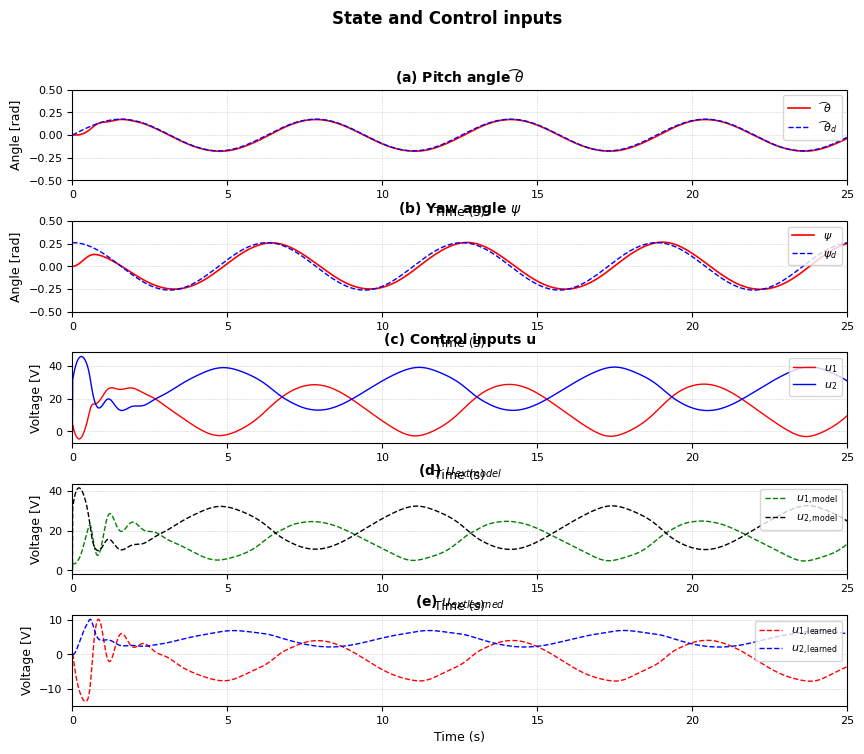

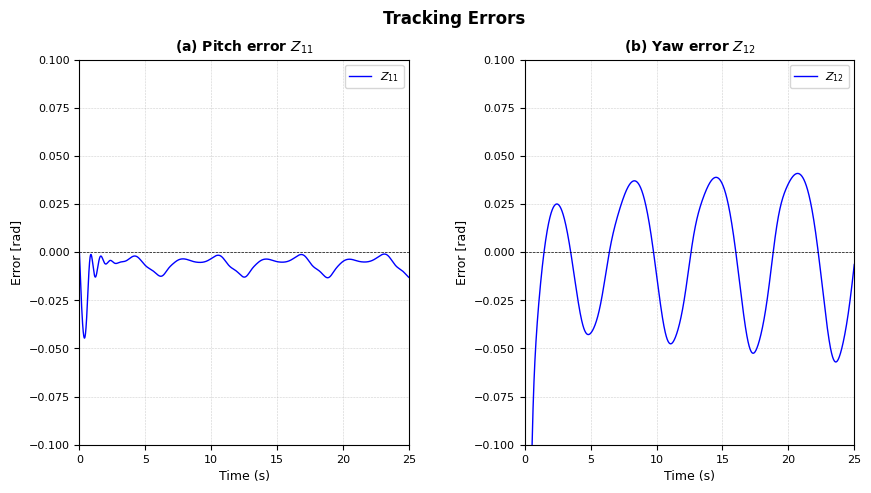

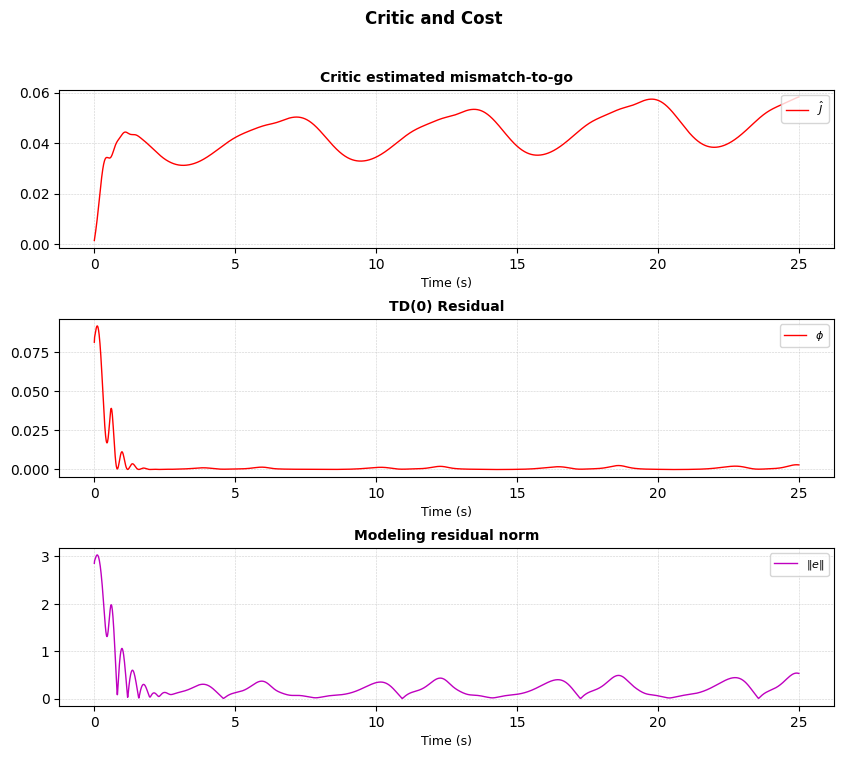

In [31]:
#DT = 0.001    # integration step [s]
DT = 0.01    # integration step [s]
T  = 25.0     # simulation duration [s]
learning = False
learning = True

run_rlc(dt = DT, T = T, seed = 42, learning = learning)

plot_results(env)

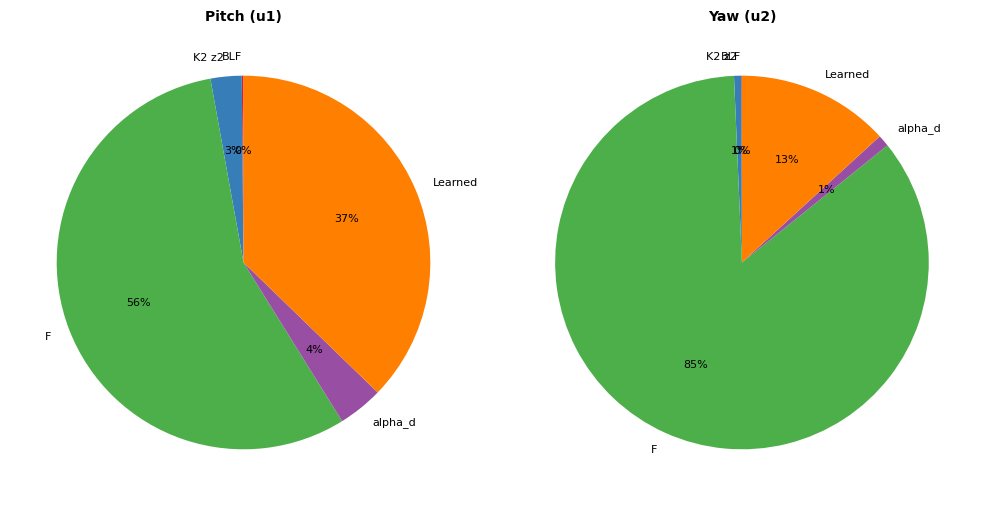

In [32]:
def plot_control_pie(t_hist, u_hist, u_blf_hist, u_k2_hist,
                     u_F_hist, u_ad_hist, u_learned_hist):
    u = np.array(u_hist)
    terms = {
        'BLF':      -np.array(u_blf_hist),
        'K2 z2':    -np.array(u_k2_hist),
        'F':        -np.array(u_F_hist),
        'alpha_d':  +np.array(u_ad_hist),
        'Learned':  -np.array(u_learned_hist),
    }
    u_mag = np.abs(u)
    u_mag = np.where(u_mag < 1e-10, np.nan, u_mag)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    labels_ch = ['Pitch (u1)', 'Yaw (u2)']
    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
    for ch in range(2):
        ax = axes[ch]
        sizes = [np.nanmean(np.abs(val[:, ch]) / u_mag[:, ch])
                 for val in terms.values()]
        ax.pie(sizes, labels=terms.keys(), colors=colors, autopct='%1.0f%%',
               startangle=90, textprops={'fontsize': 8})
        ax.set_title(labels_ch[ch], fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

t_hist, _ = env.data('theta')
plot_control_pie(t_hist, u_hist, u_blf_hist, u_k2_hist,
                 u_F_hist, u_ad_hist, u_learned_hist)

In [33]:
u = np.array(u_hist)
contr = {
    'u_blf':     -np.array(u_blf_hist),
    'u_k2':      -np.array(u_k2_hist),
    'u_F':       -np.array(u_F_hist),
    'u_ad':      +np.array(u_ad_hist),
    'u_learned': -np.array(u_learned_hist),
}
t = np.array(t_hist)
step = max(1, round(0.1 / DT))
ch_name, ch = 'PITCH', 0
print(f'{"="*75}')
print(f'  {ch_name} (every {DT*step:.3f}s)')
print(f'{"="*75}')
hdr = f'{"t(s)":>8s} {"u_total":>10s} {"u_blf":>10s} {"u_k2":>10s} {"u_F":>10s} {"u_ad":>10s} {"u_learned":>10s}'
print(hdr)
print('-' * len(hdr))
for i in range(0, len(t), step):
    vals = [u[i, ch]] + [c[i, ch] for c in contr.values()]
    print(f'{t[i]:8.3f} {vals[0]:10.3f} {vals[1]:10.3f} {vals[2]:10.3f} {vals[3]:10.3f} {vals[4]:10.3f} {vals[5]:10.3f}')
print(f'{"-"*len(hdr)}')

  PITCH (every 0.100s)
    t(s)    u_total      u_blf       u_k2        u_F       u_ad  u_learned
--------------------------------------------------------------------------
   0.000      0.000     -0.000     -0.000     -0.000      0.000     -0.000
   0.100     -2.011     -0.149     -2.506     -3.160      1.932      5.525
   0.200     -4.451     -0.126     -1.880    -11.263      2.880      9.844
   0.300     -3.272     -0.099     -1.284    -15.318      3.354     12.433
   0.400      1.073     -0.073     -0.798    -15.085      3.344     13.718
   0.500      7.788     -0.052     -0.479    -10.927      2.908     12.978
   0.600     15.064     -0.040     -0.364     -3.229      2.133      6.577
   0.700     16.646     -0.035     -0.369      4.963      1.437     -4.203
   0.800     17.261     -0.031     -0.334     10.230      1.156     -9.689
   0.900     19.290     -0.026     -0.249     13.507      1.081     -9.273
   1.000     22.272     -0.017     -0.145     15.809      1.016     -4.697
  

#### Yaw Control Signal Table

In [34]:
ch_name, ch = 'YAW', 1
print(f'{"="*75}')
print(f'  {ch_name} (every {DT*step:.3f}s)')
print(f'{"="*75}')
hdr = f'{"t(s)":>8s} {"u_total":>10s} {"u_blf":>10s} {"u_k2":>10s} {"u_F":>10s} {"u_ad":>10s} {"u_learned":>10s}'
print(hdr)
print('-' * len(hdr))
for i in range(0, len(t), step):
    vals = [u[i, ch]] + [c[i, ch] for c in contr.values()]
    print(f'{t[i]:8.3f} {vals[0]:10.3f} {vals[1]:10.3f} {vals[2]:10.3f} {vals[3]:10.3f} {vals[4]:10.3f} {vals[5]:10.3f}')
print(f'{"-"*len(hdr)}')

  YAW (every 0.100s)
    t(s)    u_total      u_blf       u_k2        u_F       u_ad  u_learned
--------------------------------------------------------------------------
   0.000      0.000     -0.000     -0.000     -0.000      0.000     -0.000
   0.100     39.548      0.128      1.954     33.207      0.953     -0.668
   0.200     44.286      0.163      1.920     37.700     -0.015     -2.867
   0.300     45.465      0.181      1.748     40.180     -0.992     -5.280
   0.400     43.668      0.178      1.453     40.464     -1.871     -7.478
   0.500     38.792      0.153      1.060     38.677     -2.567     -9.259
   0.600     29.132      0.110      0.636     34.875     -2.864    -10.027
   0.700     19.453      0.062      0.313     30.365     -2.406     -7.266
   0.800     14.931      0.028      0.163     27.025     -1.466     -4.960
   0.900     14.523      0.017      0.177     24.705     -0.546     -4.106
   1.000     16.783      0.024      0.271     23.127     -0.032     -4.069
   1

## References

[1] Zhao et al., "Reinforcement Learning Control for a 2-DOF Helicopter With State Constraints: Theory and Experiments" IEEE Trans. Autom. Sci. Eng., Vol. 21, No. 1, Jan 2024. [DOI: 10.1109/TASE.2022.3215738](https://cogno.pusan.ac.kr/sites/cogno/2024/2024_260.pdf)  
[2] Quanser Inc., “Quanser 2-DOF Helicopter Laboratory Manual,” Quanser Aerospace, Instructor Manual, 2011.